# Assignment-4

This notebook contains the coding questions to test the proficiency in `Object Oriented Programming` in python.

### Date: 13th September, 2026

### Steps to solve and upload the assignment 

- Download the notebook in your local machine.
- Solve the questions in the notebook and save it.
- Rename the file as `Assignment-04-<your_name>_<your_surname>.ipynb`. For example if your name is Dipika Chopra then name the file as `Assignment-04-Dipika_Chopra.ipynb`.
- Upload the solved notebook in your github repo under the folder **Assignment-4**.
- Upload the solved notebook in the google drive location: https://drive.google.com/drive/folders/1orNSmlOr2wMcrnu6zYeLwsY_JeUodCUq?usp=drive_link 
<h3><span style="color:red"> Deadline: 30th Sep, 2026 </span></h3>

## Problem-1

Design a system for a library. Include classes for `Book`, `Patron`, and `Library`.

- The `Book` class should have attributes for title, author, ISBN, and a method `is_available()` that returns `True` if the book is not currently checked out and `False` otherwise. It should also have a method `check_out()` that marks the book as checked out and a method `check_in()` that marks it as available.
- The `Patron` class should have attributes for name and patron ID and a method `borrow_book(book)` that associates a book with the patron.
- The `Library` class should have a collection of `Book` objects and `Patron` objects. It should have methods to `add_book(book)`, `add_patron(patron)`, `lend_book(book, patron)`, and `return_book(book)`. The `lend_book` method should only allow a book to be lent if it's available and the patron exists in the library.


Test your implementation.

In [5]:
class Book:
    def __init__(self, title, author, ISBN):
        self.title = title
        self.author = author
        self.ISBN = ISBN
        self.checked_out = False

    def is_available(self):
        return not self.checked_out

    def check_out(self):
        self.checked_out = True
        print(f"Book checked out '{self.title}'.")

    def check_in(self):
        self.checked_out = False
        print(f"Book checked in '{self.title}'.")
 
class Patron:
    def __init__(self, name, patronID):
        self.name = name
        self.patronID = patronID
        self.borrowed_books = []

    def borrow_book(self, book: Book):
        self.borrowed_books.append(book)
        book.check_out()
        print(f"Book borrowed '{book.title}'.")
    
    def return_book(self, book: Book):
        if book in self.borrowed_books:
            self.borrowed_books.remove(book)
            book.check_in()
            print(f"Book returned '{book.title}'.")

class Library:
    def __init__(self):
        self.books = []
        self.patrons = []
    
    def add_book(self, book: Book):
        self.books.append(book)
    
    def add_patron(self, patron: Patron):
        self.patrons.append(patron)

    def lend_book(self, book: Book, patron: Patron):
        if book in self.books and  book.is_available() and patron in self.patrons:
            patron.borrow_book(book)
            print(f"Successfully lent '{book.title}' to {patron.name}.")
        else:
            print(f"Lending Failed: '{book.title}' is unavailable or {patron.name} is not registered.")

    def return_book(self, book: Book):
        for patron in self.patrons:
            if book in patron.borrowed_books:
                patron.return_book(book)
                print(f"Successfully returned '{book.title}'.")
                return
        book.check_in()


In [6]:
print("--- Initializing Library System ---")
my_library = Library()

# Create books and patrons
book1 = Book("The Hobbit", "J.R.R. Tolkien", "978-0261103344")
book2 = Book("1984", "George Orwell", "978-0451524935")

patron1 = Patron("Alice Smith", "P001")
patron2 = Patron("Bob Jones", "P002") # Unregistered patron for testing

# Register items to the library system
my_library.add_book(book1)
my_library.add_book(book2)
my_library.add_patron(patron1) 
# Note: patron2 (Bob) is purposely NOT added to my_library.patrons

print("\n--- Testing Scenario 1: Successful Lending ---")
# Alice attempts to borrow "The Hobbit" (Should succeed)
my_library.lend_book(book1, patron1)

print("\n--- Testing Scenario 2: Double Borrowing Block ---")
# Alice tries to borrow "The Hobbit" again immediately (Should fail)
my_library.lend_book(book1, patron1)

print("\n--- Testing Scenario 3: Unregistered Patron Block ---")
# Bob (who is not in the system) tries to borrow "1984" (Should fail)
my_library.lend_book(book2, patron2)

print("\n--- Testing Scenario 4: Return and Re-borrow ---")
# Alice returns "The Hobbit"
my_library.return_book(book1)
# Alice tries to borrow "The Hobbit" again (Should succeed now)
my_library.lend_book(book1, patron1)

--- Initializing Library System ---

--- Testing Scenario 1: Successful Lending ---
Book checked out 'The Hobbit'.
Book borrowed 'The Hobbit'.
Successfully lent 'The Hobbit' to Alice Smith.

--- Testing Scenario 2: Double Borrowing Block ---
Lending Failed: 'The Hobbit' is unavailable or Alice Smith is not registered.

--- Testing Scenario 3: Unregistered Patron Block ---
Lending Failed: '1984' is unavailable or Bob Jones is not registered.

--- Testing Scenario 4: Return and Re-borrow ---
Book checked in 'The Hobbit'.
Book returned 'The Hobbit'.
Successfully returned 'The Hobbit'.
Book checked out 'The Hobbit'.
Book borrowed 'The Hobbit'.
Successfully lent 'The Hobbit' to Alice Smith.


## Problem-2

Create an base class `Shape` with an method `area()` and another method `perimeter()`. Then, create classes `Rectangle` and `Circle` that inherit from `Shape` and implement the `area()` method. The `perimeter()` method in `Shape` should raise a `NotImplementedError`. Implement the `perimeter()` method in `Rectangle` and `Circle`.

Test your implementation.

In [9]:
import math

class Shape:
    def area(self):
        pass
    def perimeter(self):
        raise NotImplementedError("Subclasses must implement this method!")

class Rectangle(Shape):
    def __init__(self, length, width):
        super().__init__()
        self.length = length
        self.width = width

    def area(self):
        return self.length * self.width

    def perimeter(self):
        return 2 * (self.length + self.width)

class Circle(Shape):
    def __init__(self, radius):
        super().__init__()
        self.radius = radius

    def area(self):
        return math.pi * (self.radius ** 2)

    def perimeter(self):
        return 2 * math.pi * self.radius

print("--- Testing Rectangle ---")
rect = Rectangle(5, 10)
print(f"Rectangle Area: {rect.area()}")
print(f"Rectangle Perimeter: {rect.perimeter()}")

print("\n--- Testing Circle ---")
circle = Circle(4)
print(f"Circle Area: {circle.area():.2f}")
print(f"Circle Perimeter: {circle.perimeter():.2f}")

print("\n--- Testing Base Class Error ---")
unknown_shape = Shape()
try:
    unknown_shape.perimeter()
except NotImplementedError as e:
    print(f"Caught expected error: {e}")


--- Testing Rectangle ---
Rectangle Area: 50
Rectangle Perimeter: 30

--- Testing Circle ---
Circle Area: 50.27
Circle Perimeter: 25.13

--- Testing Base Class Error ---
Caught expected error: Subclasses must implement this method!


## Problem-3

Design a system to model different types of employees in a company. There should be a base `Employee` class with attributes for `name` and `employee_id`. Create two subclasses: `SalariedEmployee` with an attribute for `monthly_salary` and a method `calculate_paycheck()` that returns the monthly salary, and `HourlyEmployee` with attributes for `hourly_rate` and `hours_worked`, and a `calculate_paycheck()` method that returns the total pay for the week. Demonstrate creating instances of both employee types and calling their `calculate_paycheck()` methods.

Test your implementation.

In [12]:
class Employee:
    def __init__(self, name, emp_id):
        self.name = name
        self.emp_id = emp_id

class SalariedEmployee(Employee):
    def __init__(self, name, emp_id, montly_salary):
        super().__init__(name, emp_id)
        self.montly_salary = montly_salary

    def calculate_paycheck(self):
        return self.montly_salary

class HourlyEmployee(Employee):
    def __init__(self, name, emp_id, hourly_rate, hours_worked):
        super().__init__(name, emp_id)
        self.hourly_rate = hourly_rate
        self.hours_worked = hours_worked

    def calculate_paycheck(self):
        return self.hourly_rate * self.hours_worked


salaried_emp = SalariedEmployee("Alice", 121345, montly_salary=1_000_000)
hourly_emp = HourlyEmployee("Bob", 123431, hourly_rate=1_000, hours_worked=8)

print(f"Employee: {salaried_emp.name} ({salaried_emp.emp_id})")
print(f"Type: Salaried | Monthly Paycheck Amount: ${salaried_emp.calculate_paycheck()}")

print(f"Employee: {hourly_emp.name} ({hourly_emp.emp_id})")
print(f"Type: Hourly | Hourly Paycheck Amount: ${hourly_emp.calculate_paycheck()}")

Employee: Alice (121345)
Type: Salaried | Monthly Paycheck Amount: $1000000
Employee: Bob (123431)
Type: Hourly | Hourly Paycheck Amount: $8000


## Problem-4

Design a class `polynomial` of one variable which will have attributes `degree`, a positive integer and `coefficients`, a list of floating point numbers. 
`degree` means the highest power of the variable and `coefficients` are the coefficient of individual terms.

A polynomial of degree `n` has `n+1` coefficients. 

- Example-1:
$$ 3x^4 + 5x^3 + x^2 + 9x + 10 $$
This is a polynomial of degree 4 and coefficients are [3, 5, 1, 9, 10].

- Example-2: (some coefficients could be zero)
$$ 0.7x^3 + 2.5x $$
Here the degree of polynomial is 3 and coefficients are [0.7, 0, 2.5, 0].

A polynomial of degree zero is just a constant value. 

In the `polynomial` class, you need to implement the following methods:
- `evaluate(x)` which will evaluate the polynomial for a given value of the variable x.
- `plot([x1, x2])` this will plot the polynomial for a given range of x1 to x2 of the variable.
- `derivative(x)` This will evaluate the derivative (differentiation) of the polynomial for a given value of the variable x.
- `plot_derivative([x1, x2])` this will plot the derivative of the polynomial for a given range of x1 to x2 of the variable.

The class should have basic checks, such that the number of coefficients provided by the user should be degree + 1 and the degree should be a positive integer. 

Test your implementation. 

Value of f(x) for x = 2, is 11


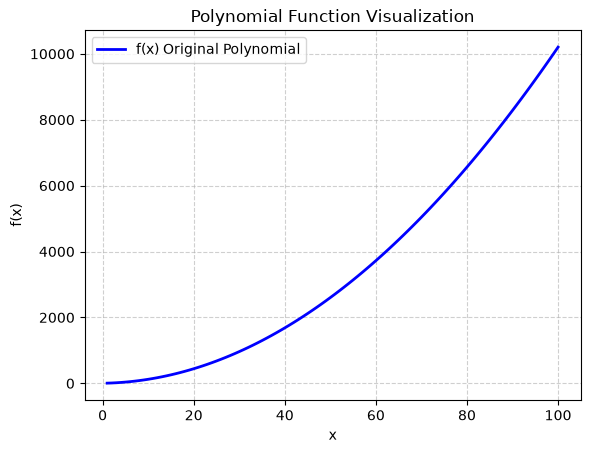

Value of f'(x) for x = 2, is 6


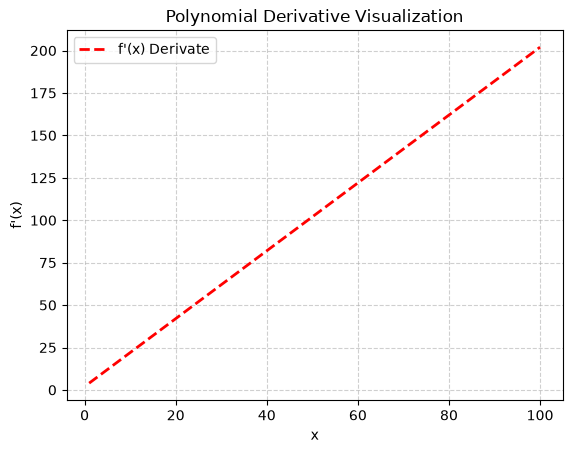

In [25]:
import matplotlib.pyplot as plt

class Polynomial:
    def __init__(self, degree, coefficients):
        if len(coefficients) != degree + 1:
            raise ValueError(f"For degree {degree}, you must provide exactly {degree + 1} coefficients.")
        elif degree <= 0:
            raise ValueError(f"Degree must be a positive integer greater than 0.")
        else:
            self.degree = degree
            self.coefficients = coefficients


    def evaluate(self, x):
        result = 0
        for i, coeff in enumerate(self.coefficients):
            power = self.degree - i
            result += coeff * (x ** power)
        return result

    def plot(self, nums):
        x1, x2 = nums

        x_vals = list(range(int(x1), int(x2) + 1))
        y_vals = [self.evaluate(x) for x in x_vals]

        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.plot(x_vals, y_vals, label="f(x) Original Polynomial", color="blue", linewidth=2)
        plt.title("Polynomial Function Visualization")
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.legend()
        plt.show()

    def derivate(self, x):
        result = 0
        for i in range(self.degree):
            coeff = self.coefficients[i]
            power = self.degree - i
            result += coeff * power * x ** (power - 1)
        return result

    def plot_derivative(self, nums):
        x1, x2 = nums
        
        x_vals = list(range(int(x1), int(x2) + 1))
        y_vals = [self.derivate(x) for x in x_vals]

        plt.xlabel("x")
        plt.ylabel("f'(x)")
        plt.plot(x_vals, y_vals, label="f'(x) Derivate", color="red", linestyle="--", linewidth=2)
        plt.title("Polynomial Derivative Visualization")
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.legend()
        plt.show()

polynomial = Polynomial(2, [1, 2, 3])
value = 2
print(f"Value of f(x) for x = {value}, is {polynomial.evaluate(2)}")
polynomial.plot([1, 100])
print(f"Value of f'(x) for x = {value}, is {polynomial.derivate(2)}")
polynomial.plot_derivative([1, 100])

## Problem-5

Design a system to model a simple online shopping cart. Create a class `Product` with attributes for `name` and `price`. Then, create a `ShoppingCart` class that has a list to store `Product` objects. Implement methods to `add_item(product)`, `remove_item(product_name)`, and `calculate_total()`.

In [28]:
class Product:
    def __init__(self, name, price):
        self.name = name
        self.price = price

class ShoppingCart:
    def __init__(self):
        self.products = []

    def add_item(self, product: Product):
        self.products.append(product)

    def remove_item(self, product_name):
        self.products = [product for product in self.products if product.name != product_name]

    def calculate_total(self):
        return sum([product.price for product in self.products])

print("--- 1. Creating Available Products ---")
laptop = Product("Laptop", 1200.00)
mouse = Product("Wireless Mouse", 25.50)
headphones = Product("Noise Cancelling Headphones", 150.00)

print(f"Product Created: {laptop.name} (${laptop.price})")
print(f"Product Created: {mouse.name} (${mouse.price})")
print(f"Product Created: {headphones.name} (${headphones.price})")

print("\n--- 2. Initializing Cart and Adding Items ---")
cart = ShoppingCart()

cart.add_item(laptop)
cart.add_item(mouse)
cart.add_item(headphones)
print(f"Added 3 items to the cart. Current count: {len(cart.products)}")

print("\n--- 3. Checking Initial Cart Total ---")
initial_total = cart.calculate_total()
print(f"Total Price: ${initial_total:,.2f}")

print("\n--- 4. Removing an Item ---")
cart.remove_item("Wireless Mouse")
print("Removed 'Wireless Mouse' from the cart.")
print(f"Current remaining items count: {len(cart.products)}")

print("\n--- 5. Checking Updated Cart Total ---")
updated_total = cart.calculate_total()
print(f"New Total Price: ${updated_total:,.2f}")


--- 1. Creating Available Products ---
Product Created: Laptop ($1200.0)
Product Created: Wireless Mouse ($25.5)
Product Created: Noise Cancelling Headphones ($150.0)

--- 2. Initializing Cart and Adding Items ---
Added 3 items to the cart. Current count: 3

--- 3. Checking Initial Cart Total ---
Total Price: $1,375.50

--- 4. Removing an Item ---
Removed 'Wireless Mouse' from the cart.
Current remaining items count: 2

--- 5. Checking Updated Cart Total ---
New Total Price: $1,350.00
